## Análise de Dados do Teste do Pezinho(Qualidade das amostras)

###  Fonte dos Dados

A análise utiliza um conjunto de cinco arquivos CSV:

-   `tb_amostra.csv`: Tabela principal contendo os registros de cada amostra coletada.
-   `tb_motivo_inadequacao.csv`: Tabela de catálogo com as descrições dos motivos de inadequação.
-   `tb_ms_motivo_inadequacao.csv`: Tabela de ligação entre as amostras e os motivos de inadequação.
-   `tb_municipio.csv`: Tabela com informações sobre os municípios.
-   `tb_unidade_saude.csv`: Tabela com dados das unidades de saúde onde as coletas foram realizadas.

### ⚙️ Passos da Análise

O processo de análise foi estruturado da seguinte forma:

1.  **Configuração do Ambiente**: Importação das bibliotecas necessárias para a análise, como `pandas`, `matplotlib` e `seaborn`.
2.  **Carregamento dos Dados**: Leitura dos cinco arquivos CSV para DataFrames do `pandas`.
3.  **Análise de Cancelamentos**:
    *   Identificação das amostras canceladas (taxa de 0.11% do total).
    *   Análise de quem são os usuários que mais realizam cancelamentos.
4.  **Investigação dos Motivos de Inadequação**:
    *   Tentativa de cruzar as amostras canceladas com seus respectivos motivos.
    *   **Principal achado**: A grande maioria das amostras canceladas (cerca de 97%) não possui um motivo de cancelamento registrado no sistema, o que indica uma falha importante no processo de documentação.
5.  **Análise Geográfica**:
    *   Cruzamento dos dados de cancelamento com as unidades de saúde e os municípios.
    *   Identificação das unidades de saúde e municípios com maior número de cancelamentos.
    *   Visualização dos dados em gráficos de barras e de pizza para ilustrar a concentração geográfica.

### 📊 Principais Insights e Conclusões

-   **Falta de Documentação**: O principal problema identificado é a ausência de registro dos motivos para a maioria dos cancelamentos, dificultando a análise da causa raiz.
-   **Concentração Geográfica**: Os cancelamentos não são distribuídos uniformemente. Há uma forte concentração em alguns municípios, com destaque para **São Luís**, que representa mais de 21% de todas as amostras canceladas.
-   **Ação Recomendada**: A análise sugere que fatores locais (como treinamento, processos ou infraestrutura) em municípios específicos podem estar influenciando diretamente a taxa de cancelamento. Uma investigação mais aprofundada nessas localidades é recomendada.

### 🛠️ Tecnologias Utilizadas

-   **Python**: Linguagem de programação.
-   **Pandas**: Para manipulação e análise dos dados.
-   **Matplotlib & Seaborn**: Para a criação das visualizações gráficas.
-   **Jupyter Notebook**: Como ambiente de desenvolvimento interativo.


In [2]:
# ====================================================================
# PASSO 0: CONFIGURAÇÃO DO AMBIENTE
# ====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
#sns.set_palette("husl")
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', 20)

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [3]:
# ====================================================================
# PASSO 1: CARREGAMENTO E INSPEÇÃO INICIAL
# ====================================================================

# Carregar as tabelas
df_amostra = pd.read_csv('./datasets/tb_amostra.csv')
df_motivo_inadequacao = pd.read_csv('./datasets/tb_motivo_inadequacao.csv')
df_ms_motivo_inadequacao = df_ms_motivo_inadequacao = pd.read_csv('./datasets/tb_ms_motivo_inadequacao.csv')
df_municipio = df_municipio = pd.read_csv('./datasets/tb_municipio.csv')
df_unidade_saude = df_unidade_saude = pd.read_csv('./datasets/tb_unidade_saude.csv')

# Visão geral das tabelas
print("VISÃO GERAL DAS TABELAS")
print(f"tb_amostra: {df_amostra.shape}")
print(f"tb_motivo_inadequacao: {df_motivo_inadequacao.shape}")
print(f"tb_ms_motivo_inadequacao: {df_ms_motivo_inadequacao.shape}")
print(f"tb_municipio: {df_municipio.shape}")
print(f"tb_unidade_saude: {df_unidade_saude.shape}")

# Amostra inicial da tabela principal
print("AMOSTRA DA TABELA DE AMOSTRAS")
df_amostra.head(2)

VISÃO GERAL DAS TABELAS
tb_amostra: (554474, 19)
tb_motivo_inadequacao: (24, 7)
tb_ms_motivo_inadequacao: (16, 3)
tb_municipio: (5565, 17)
tb_unidade_saude: (1419, 20)
AMOSTRA DA TABELA DE AMOSTRAS


,co_seq_amostra,co_seq_tp_amostra,co_seq_pessoa,co_seq_tp_material_coletado,co_seq_unidade_saude,nu_amostra,ide_controle_medico,ide_portador,dt_col_amostra,hr_col_amostra,dt_post_amostra,dt_rec_amostra,dt_hr_cancelamento,aut_cancelamento,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_transfusao_amostra
0,80645,1,79939,1,622,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080559,carliane,20190716080559,carliane,N
1,80646,1,79940,1,623,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080714,carliane,20190716080714,carliane,N


🔍 Passo 2: Identificação de Amostras Canceladas/Inadequadas


In [4]:
# Verificar se há colunas que podem conectar as tabelas
print("VERIFICANDO POSSÍVEIS CONEXÕES")

# Verificar se há colunas com 'motivo' ou 'inadeq' em df_amostra
motivo_cols = [col for col in df_amostra.columns if 'motivo' in col.lower() or 'inadeq' in col.lower()]
print(f"Colunas relacionadas a motivos em df_amostra: {motivo_cols}")

# Verificar a estrutura da tabela de relacionamento
print(f"\ndf_ms_motivo_inadequacao - Amostra de dados:")
print(df_ms_motivo_inadequacao.head())

# Verificar se há amostras que aparecem na tabela de relacionamento
print(f"\nQuantidade de registros na tabela de relacionamento: {len(df_ms_motivo_inadequacao)}")

# Verificar se há amostras canceladas que também têm motivos registrados
if 'co_seq_amostra' in df_ms_motivo_inadequacao.columns:
    amostras_com_motivo = df_ms_motivo_inadequacao['co_seq_amostra'].unique()
    amostras_canceladas = df_amostra[df_amostra['dt_hr_cancelamento'].notna()]['co_seq_amostra'].unique()

    print(f"\nAmostras com registro de motivo: {len(amostras_com_motivo)}")
    print(f"Amostras canceladas: {len(amostras_canceladas)}")

    # Interseção entre amostras canceladas e com motivo
    intersecao = set(amostras_com_motivo) & set(amostras_canceladas)
    print(f"Amostras que são canceladas E têm motivo registrado: {len(intersecao)}")

VERIFICANDO POSSÍVEIS CONEXÕES
Colunas relacionadas a motivos em df_amostra: []

df_ms_motivo_inadequacao - Amostra de dados:
   co_seq_ms_motivo_inadequacao  co_mot_inadequacao  co_mot_inad
0                             1                   1            1
1                             2                   2            2
2                             3                   3            3
3                             4                   4            4
4                             5                   5            5

Quantidade de registros na tabela de relacionamento: 16


In [5]:
# Realizar o relacionamento entre as tabelas para obter os motivos
print("RELACIONANDO AMOSTRAS COM MOTIVOS DE INADEQUAÇÃO")

#  juntar df_ms_motivo_inadequacao com df_motivo_inadequacao
# para obter as descrições dos motivos
motivos_com_descricao = df_ms_motivo_inadequacao.merge(
    df_motivo_inadequacao,
    left_on='co_mot_inadequacao',
    right_on='co_mot_inadequacao',
    how='left'
)

print(f"Motivos com descrição - Amostra:")
print(motivos_com_descricao[['co_seq_ms_motivo_inadequacao', 'co_mot_inadequacao', 'ds_mot_inadequacao']].head())

# juntar com a tabela de amostras para ver os motivos das amostras canceladas
amostras_com_motivos = df_amostra.merge(
    motivos_com_descricao,
    left_on='co_seq_amostra',
    right_on='co_seq_ms_motivo_inadequacao',
    how='left'
)

print(f"\nAmostras com motivos - Amostra (incluindo canceladas):")
print(amostras_com_motivos[['co_seq_amostra', 'dt_hr_cancelamento', 'ds_mot_inadequacao']].head(10))


# Análise dos principais motivos de inadequação
print(f"\nPRINCIPAIS MOTIVOS DE INADEQUAÇÃO")
motivos_contagem = amostras_com_motivos['ds_mot_inadequacao'].value_counts(dropna=False)
print(motivos_contagem.head(15))



RELACIONANDO AMOSTRAS COM MOTIVOS DE INADEQUAÇÃO
Motivos com descrição - Amostra:
   co_seq_ms_motivo_inadequacao  co_mot_inadequacao  \
0                             1                   1   
1                             2                   2   
2                             3                   3   
3                             4                   4   
4                             5                   5   

                                  ds_mot_inadequacao  
0            Os cinco círculos não foram preenchidos  
1  A área do(s) círculo(s) não foi (foram) totalm...  
2      Gota muito pequena, insuficiente para análise  
3  Gota não penetrou totalmente no papel, não ati...  
4                        Múltiplas gotas sobrepostas  

Amostras com motivos - Amostra (incluindo canceladas):
   co_seq_amostra  dt_hr_cancelamento ds_mot_inadequacao
0           80645                 NaN                NaN
1           80646                 NaN                NaN
2           80596             

In [6]:
# Análise específica dos cancelamentos e seus motivos
print("ANÁLISE DETALHADA DOS CANCELAMENTOS")

# Filtrar apenas amostras canceladas
amostras_canceladas = amostras_com_motivos[amostras_com_motivos['dt_hr_cancelamento'].notna()].copy()

print(f"Total de amostras canceladas com análise de motivos: {len(amostras_canceladas)}")

# Contagem de motivos para amostras canceladas
print(f"\nDistribuição de motivos nas amostras canceladas:")
motivos_cancelamento = amostras_canceladas['ds_mot_inadequacao'].value_counts(dropna=False)
print(motivos_cancelamento)

# Percentual dos principais motivos
print(f"\nPercentual dos principais motivos de cancelamento:")
motivos_percentual = (motivos_cancelamento / len(amostras_canceladas) * 100).round(2)
for motivo, percentual in motivos_percentual.head(10).items():
    motivo_label = "SEM MOTIVO REGISTRADO" if pd.isna(motivo) else motivo
    print(f"  {motivo_label}: {percentual}%")

ANÁLISE DETALHADA DOS CANCELAMENTOS
Total de amostras canceladas com análise de motivos: 596

Distribuição de motivos nas amostras canceladas:
ds_mot_inadequacao
NaN                                                                 580
Gota muito pequena, insuficiente para análise                         1
Gota não penetrou totalmente no papel, não atingiu o verso            1
Não houve eluição (sangue não se separou do papel)                    1
Amostra recebida com mais de 15 dias após a coleta                    1
Amostra com aspecto de diluição do sangue                             1
Amostra danificada                                                    1
Outros                                                                1
Amostra coletada antes do terceiro dia                                1
Múltiplas gotas sobrepostas                                           1
Houve desnaturação da hemoglobina                                     1
Criança recebeu transfusão de sangue          

In [7]:
# Vamos investigar mais profundamente o problema dos motivos nulos
print("INVESTIGAÇÃO DETALHADA DOS MOTIVOS NULOS")

# Verificar a estrutura completa da tabela de relacionamento
print(f"\nEstrutura da tabela df_ms_motivo_inadequacao:")
print(df_ms_motivo_inadequacao.info())

print(f"\nAmostra da tabela df_ms_motivo_inadequacao:")
print(df_ms_motivo_inadequacao.head(10))

# Verificar se há outros campos que podem conter informações sobre motivos
print(f"\nColunas em df_amostra que podem conter motivos:")
colunas_suspeitas = [col for col in df_amostra.columns if 'motivo' in col.lower() or 'justif' in col.lower() or 'obs' in col.lower()]
print(colunas_suspeitas)

# Verificar se há alguma coluna de autorização que possa conter motivos
print(f"\nColunas de autorização em df_amostra:")
colunas_aut = [col for col in df_amostra.columns if 'aut_' in col]
for col in colunas_aut:
    print(f"\nValores únicos em '{col}':")
    print(df_amostra[col].value_counts(dropna=False).head(10))

# Analisar especificamente a coluna aut_cancelamento
print(f"\n=== ANÁLISE DETALHADA DA AUTORIZAÇÃO DE CANCELAMENTO ===")
print(f"Valores em 'aut_cancelamento' para amostras canceladas:")
amostras_canceladas_completo = df_amostra[df_amostra['dt_hr_cancelamento'].notna()]
print(amostras_canceladas_completo['aut_cancelamento'].value_counts(dropna=False))

# Verificar se há padrões nos textos de autorização
print(f"\nAmostra de valores em 'aut_cancelamento' (primeiros 20):")
aut_cancelamento_unicos = amostras_canceladas_completo['aut_cancelamento'].dropna().unique()[:20]
for i, valor in enumerate(aut_cancelamento_unicos):
    print(f"  {i+1}. {valor}")
    if i >= 19:  # Limitar a 20 exemplos
        print("  ... (há mais valores)")
        break

INVESTIGAÇÃO DETALHADA DOS MOTIVOS NULOS

Estrutura da tabela df_ms_motivo_inadequacao:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   co_seq_ms_motivo_inadequacao  16 non-null     int64
 1   co_mot_inadequacao            16 non-null     int64
 2   co_mot_inad                   16 non-null     int64
dtypes: int64(3)
memory usage: 516.0 bytes
None

Amostra da tabela df_ms_motivo_inadequacao:
   co_seq_ms_motivo_inadequacao  co_mot_inadequacao  co_mot_inad
0                             1                   1            1
1                             2                   2            2
2                             3                   3            3
3                             4                   4            4
4                             5                   5            5
5                             6           

In [8]:
# Verificar se há informações úteis nas tabelas de unidade de saúde e município
print("VERIFICANDO INFORMAÇÕES ADICIONAIS NAS OUTRAS TABELAS")

# Verificar a estrutura das tabelas auxiliares
print(f"\nColunas em df_unidade_saude:")
print([col for col in df_unidade_saude.columns if 'obs' in col.lower() or 'descr' in col.lower()])

print(f"\nColunas em df_municipio:")
print([col for col in df_municipio.columns if 'obs' in col.lower() or 'descr' in col.lower()])

# Verificar se há observações nas unidades de saúde
print(f"\nAmostra das colunas de observação em df_unidade_saude:")
obs_cols_unidade = [col for col in df_unidade_saude.columns if 'obs' in col.lower()]
for col in obs_cols_unidade:
    print(f"\nValores não nulos em '{col}' (amostra):")
    obs_nao_nulos = df_unidade_saude[df_unidade_saude[col].notna()][col]
    print(obs_nao_nulos.head(5))

VERIFICANDO INFORMAÇÕES ADICIONAIS NAS OUTRAS TABELAS

Colunas em df_unidade_saude:
[]

Colunas em df_municipio:
['obs_municipio']

Amostra das colunas de observação em df_unidade_saude:


ANÁLISE POR UNIDADE DE SAÚDE

Top 15 unidades com mais cancelamentos:
no_unidade_saude
SEC.MUNIC. DE ACAILANDIA                          48
APAE                                              28
MAT. MATERNO INFANTIL                             27
HOSP. INF. DR. JUVENCIO MATTOS                    25
MAC-MA                                            23
SOC MED. HOSP.C.REI                               19
HOSP.MATER-INF                                    15
MATERNIDADE DE ALTO RISCO DE IMPERATRIZ - MARI    12
HOSP. REG. DE ALTO ALEGRE                         11
MAT. CARMOS.COUTINHO                               8
U.B.S. VIANA                                       7
MAT. BENEDITO LEITE COHAB                          7
HOSP. SANTA NEUSA                                  6
HOSPITAL REGIONAL DE BALSAS                        6
U.B.S. RAIMUNDO MARÇAL                             5
Name: count, dtype: int64


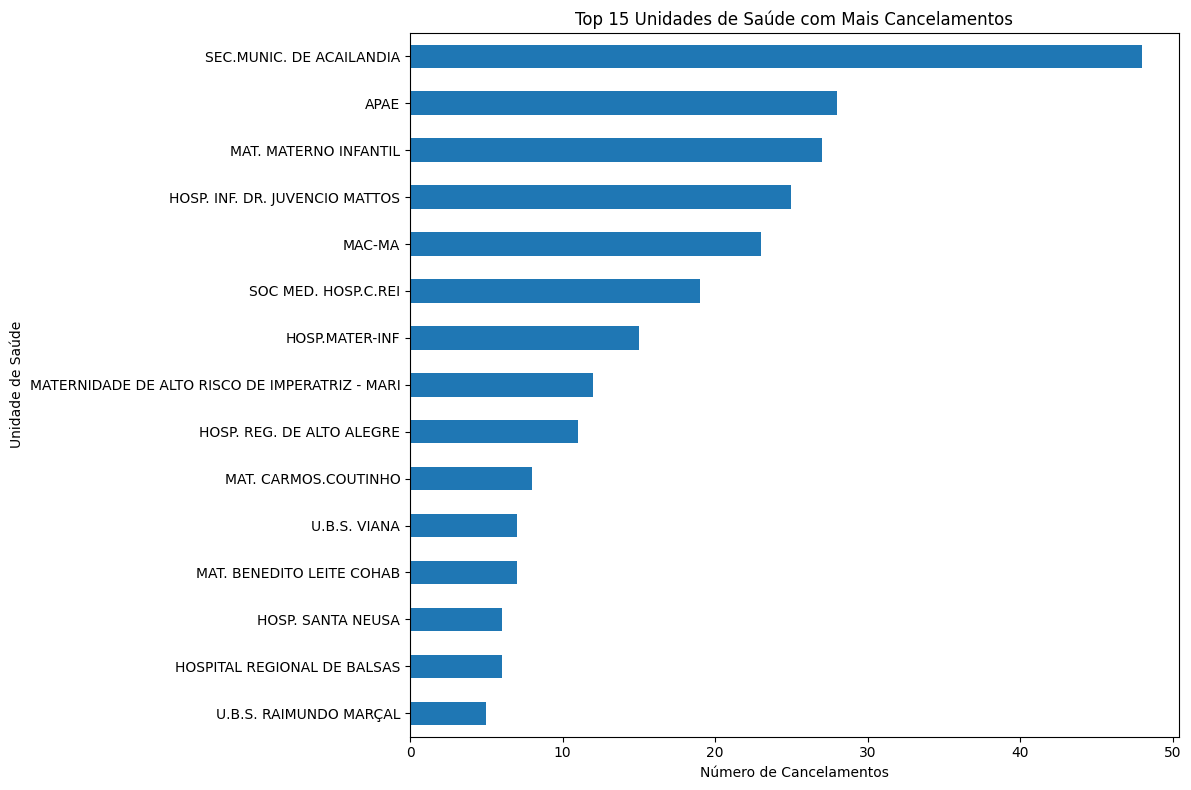

In [9]:
# Análise por unidade de saúde
print("ANÁLISE POR UNIDADE DE SAÚDE")

# Relacionar amostras canceladas com unidades de saúde
canceladas_com_unidade = amostras_canceladas.merge(
    df_unidade_saude[['co_seq_unidade_saude', 'no_unidade_saude']],
    on='co_seq_unidade_saude',
    how='left'
)

# Top 15 unidades com mais cancelamentos
print(f"\nTop 15 unidades com mais cancelamentos:")
top_unidades = canceladas_com_unidade['no_unidade_saude'].value_counts().head(15)
print(top_unidades)

# Visualizar as unidades com mais cancelamentos
plt.figure(figsize=(12, 8))
top_unidades.plot(kind='barh')
plt.title('Top 15 Unidades de Saúde com Mais Cancelamentos')
plt.xlabel('Número de Cancelamentos')
plt.ylabel('Unidade de Saúde')
plt.gca().invert_yaxis()  # Para mostrar a maior no topo
plt.tight_layout()
plt.show()

In [10]:
# Primeiro, vamos relacionar as amostras canceladas com os municípios através das unidades de saúde
print("RELACIONANDO CANCELAMENTOS COM MUNICÍPIOS")

# 1. Relacionar amostras canceladas com unidades de saúde
canceladas_com_unidade = df_amostra[df_amostra['dt_hr_cancelamento'].notna()].merge(
    df_unidade_saude,
    on='co_seq_unidade_saude',
    how='left',
    suffixes=('', '_unidade')
)

# 2. Relacionar com municípios
canceladas_com_municipio = canceladas_com_unidade.merge(
    df_municipio[['co_seq_municipio', 'no_municipio']],
    on='co_seq_municipio',
    how='left',
    suffixes=('', '_municipio')
)

print(f"Total de amostras canceladas: {len(df_amostra[df_amostra['dt_hr_cancelamento'].notna()])}")
print(f"Cancelamentos com município identificado: {canceladas_com_municipio['no_municipio'].notna().sum()}")
print(f"Percentual com município: {(canceladas_com_municipio['no_municipio'].notna().sum() / len(df_amostra[df_amostra['dt_hr_cancelamento'].notna()]) * 100):.2f}%")

RELACIONANDO CANCELAMENTOS COM MUNICÍPIOS
Total de amostras canceladas: 596
Cancelamentos com município identificado: 596
Percentual com município: 100.00%


TOP MUNICÍPIOS COM MAIS CANCELAMENTOS
Top 20 municípios com mais cancelamentos:
 1. São Luís: 127
 2. Açailândia: 50
 3. Imperatriz: 27
 4. Balsas: 25
 5. Caxias: 20
 6. Bacabal: 15
 7. Alto Alegre do Maranhão: 11
 8. Grajaú: 8
 9. Viana: 7
10. Araioses: 7
11. Mirador: 7
12. Coroatá: 7
13. Parnarama: 6
14. Porto Franco: 6
15. Timbiras: 5
16. Amarante do Maranhão: 5
17. Chapadinha: 5
18. Codó: 5
19. Cândido Mendes: 5
20. Bom Jardim: 5


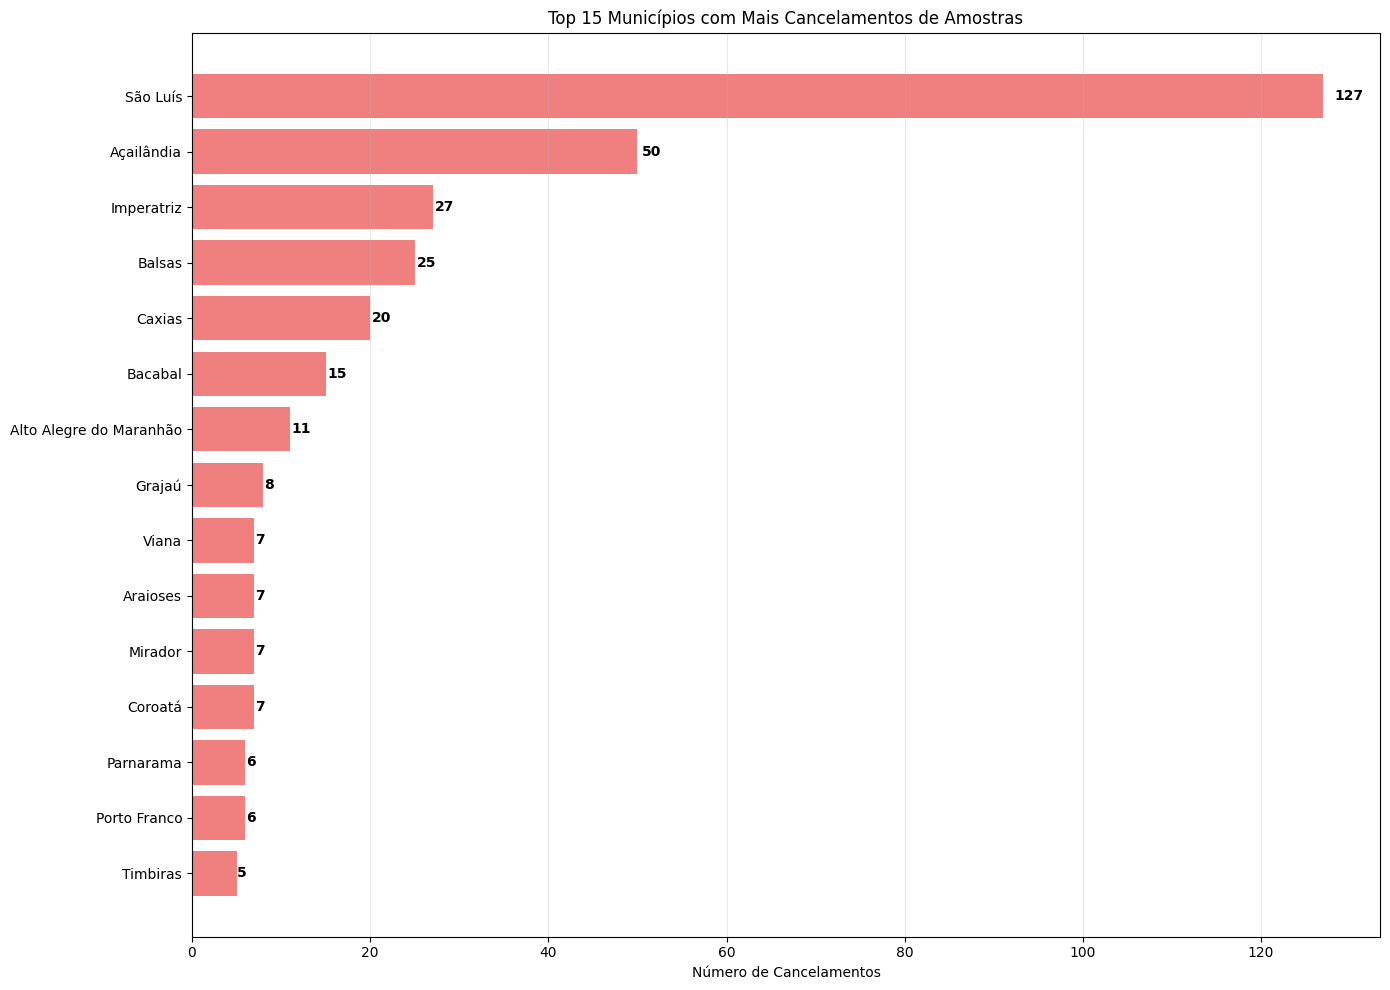

In [ ]:
# Análise dos municípios com mais cancelamentos
print("TOP MUNICÍPIOS COM MAIS CANCELAMENTOS")

# Contagem de cancelamentos por município
cancelamentos_por_municipio = canceladas_com_municipio['no_municipio'].value_counts()

# Top 20 municípios
top_20_municipios = cancelamentos_por_municipio.head(20)
print("Top 20 municípios com mais cancelamentos:")
for i, (municipio, quantidade) in enumerate(top_20_municipios.items(), 1):
    print(f"{i:2d}. {municipio}: {quantidade:,}")

# Criar visualização dos top 15 municípios
plt.figure(figsize=(14, 10))
top_15_municipios = top_20_municipios.head(15)

# Gráfico de barras horizontais
bars = plt.barh(range(len(top_15_municipios)), top_15_municipios.values, color='lightcoral')
plt.yticks(range(len(top_15_municipios)), top_15_municipios.index)
plt.xlabel('Número de Cancelamentos')
plt.title('Top 15 Municípios com Mais Cancelamentos de Amostras')
plt.gca().invert_yaxis()  # Para mostrar o maior no topo

# Adicionar valores nas barras
for i, (bar, valor) in enumerate(zip(bars, top_15_municipios.values)):
    plt.text(bar.get_width() + valor * 0.01, bar.get_y() + bar.get_height()/2,
             f'{valor:,}',
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

DISTRIBUIÇÃO PERCENTUAL DOS CANCELAMENTOS
Percentual dos top 10 municípios no total de cancelamentos:
 1. São Luís: 21.31%
 2. Açailândia: 8.39%
 3. Imperatriz: 4.53%
 4. Balsas: 4.19%
 5. Caxias: 3.36%
 6. Bacabal: 2.52%
 7. Alto Alegre do Maranhão: 1.85%
 8. Grajaú: 1.34%
 9. Viana: 1.17%
10. Araioses: 1.17%


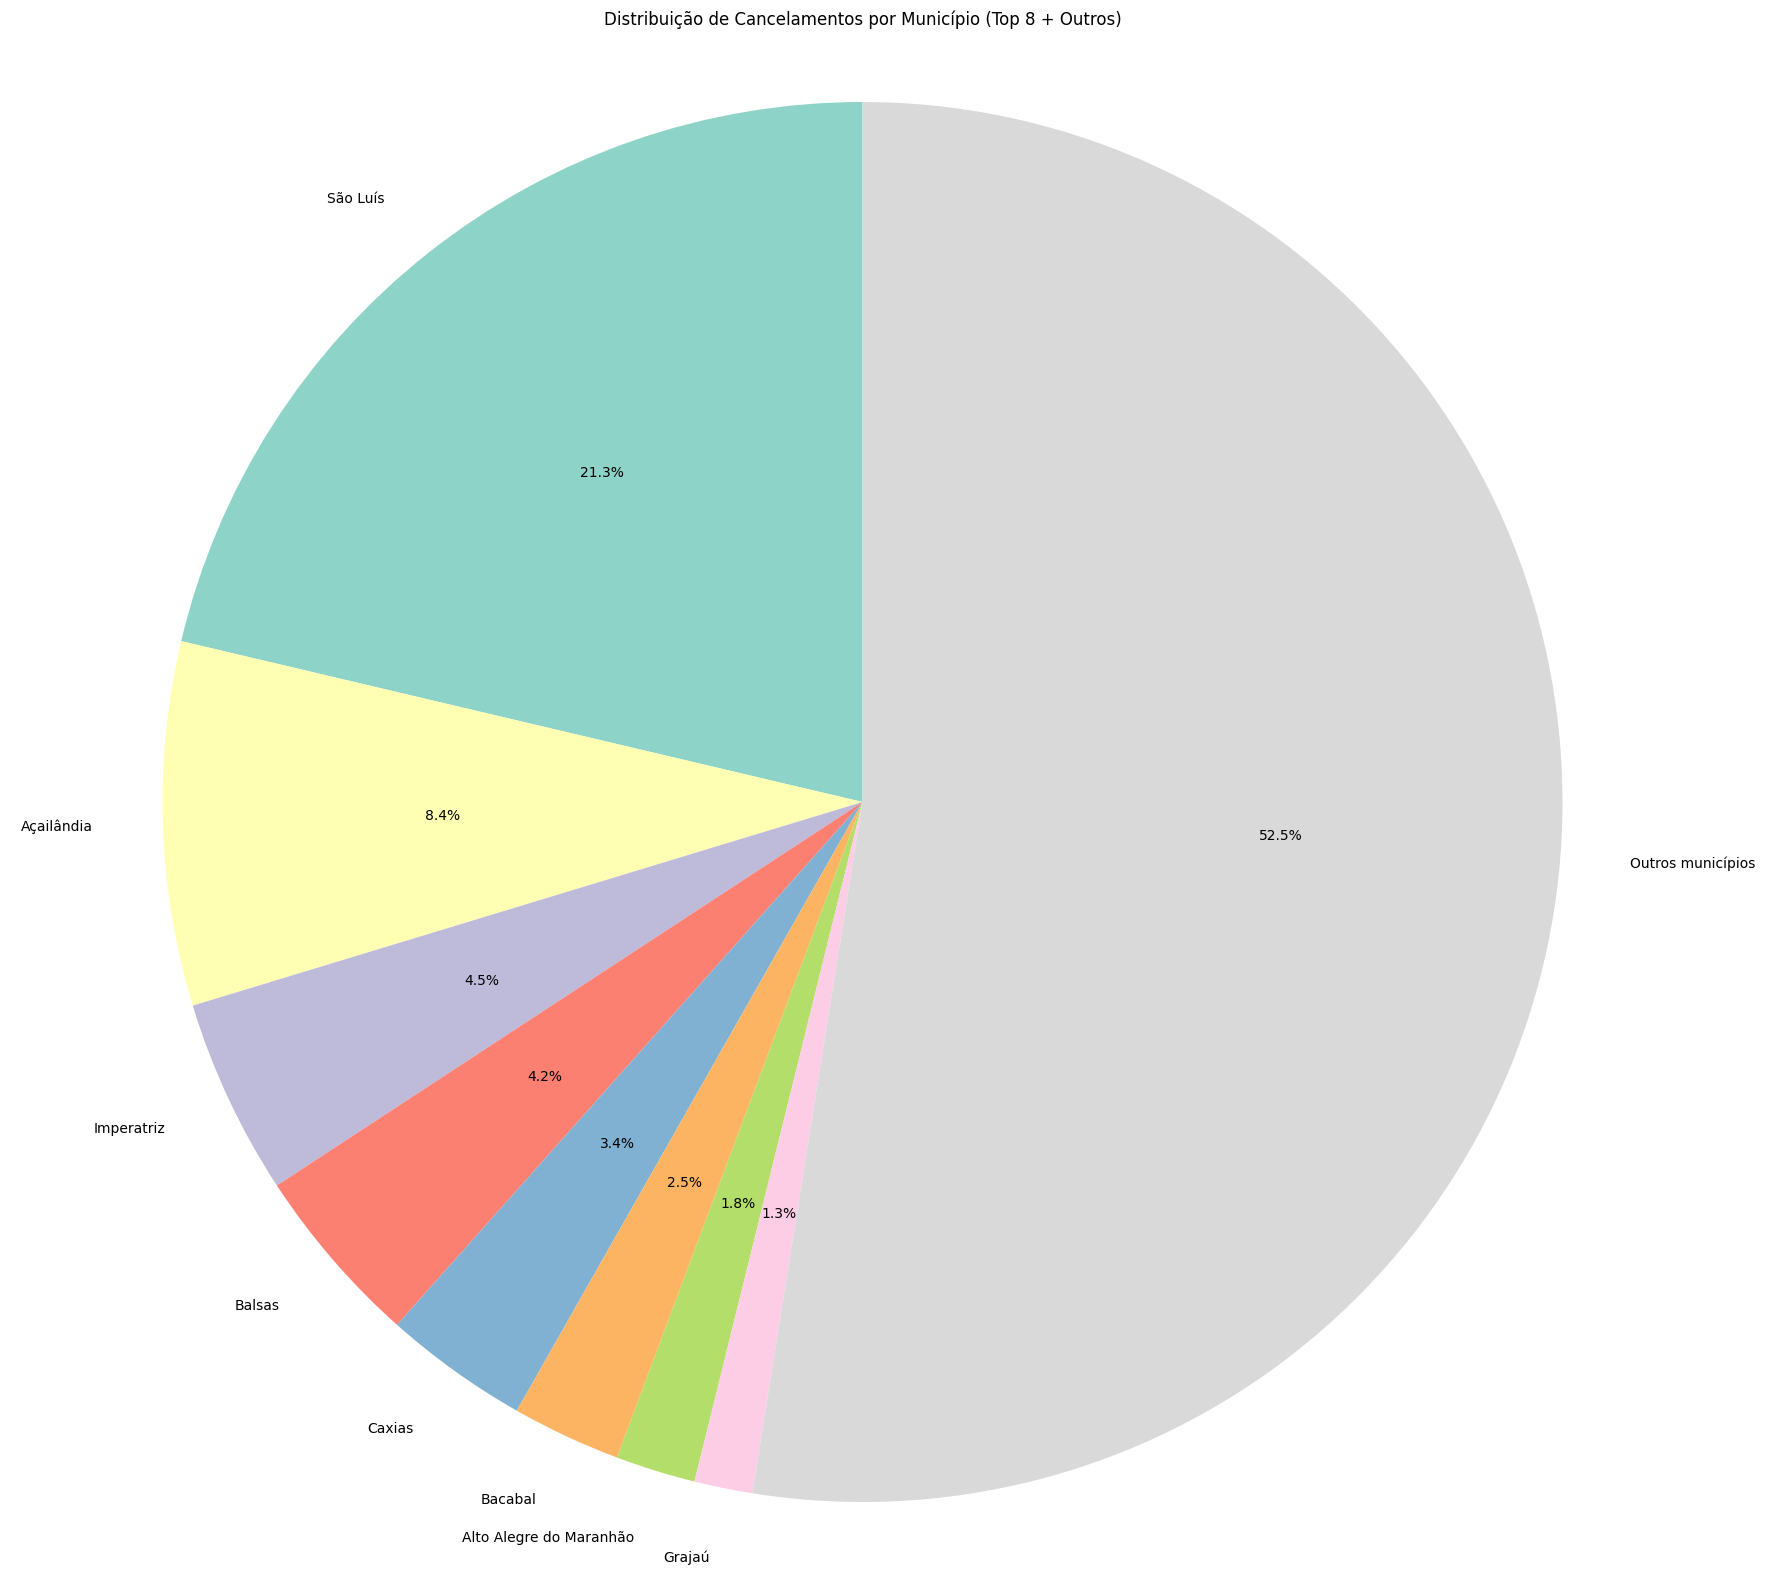


ESTATÍSTICAS RESUMIDAS
Total de municípios com cancelamentos: 140
Total de cancelamentos com município identificado: 596
Município com mais cancelamentos: São Luís (127)
Cancelamentos do município líder representam: 21.31% do total


In [12]:
# Análise percentual dos cancelamentos por município
print("DISTRIBUIÇÃO PERCENTUAL DOS CANCELAMENTOS")

# Calcular percentuais
total_cancelamentos_com_municipio = cancelamentos_por_municipio.sum()
top_10_municipios = cancelamentos_por_municipio.head(10)
percentuais = (top_10_municipios / total_cancelamentos_com_municipio * 100).round(2)

print("Percentual dos top 10 municípios no total de cancelamentos:")
for i, (municipio, percentual) in enumerate(percentuais.items(), 1):
    print(f"{i:2d}. {municipio}: {percentual:.2f}%")

# Gráfico de pizza para os top 8 municípios
plt.figure(figsize=(22, 20))
top_8_municipios = cancelamentos_por_municipio.head(8)
outros = cancelamentos_por_municipio.iloc[8:].sum()

# Preparar dados para o gráfico
labels = list(top_8_municipios.index) + ['Outros municípios']
sizes = list(top_8_municipios.values) + [outros]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Set3.colors)
plt.title('Distribuição de Cancelamentos por Município (Top 8 + Outros)')
plt.axis('equal')
plt.show()

# Mostrar estatísticas resumidas
print(f"\nESTATÍSTICAS RESUMIDAS")
print(f"Total de municípios com cancelamentos: {len(cancelamentos_por_municipio)}")
print(f"Total de cancelamentos com município identificado: {total_cancelamentos_com_municipio:,}")
print(f"Município com mais cancelamentos: {cancelamentos_por_municipio.index[0]} ({cancelamentos_por_municipio.iloc[0]:,})")
print(f"Cancelamentos do município líder representam: {(cancelamentos_por_municipio.iloc[0] / total_cancelamentos_com_municipio * 100):.2f}% do total")

In [13]:
# Resumo executivo dos principais insights
print("RESUMO EXECUTIVO - ANÁLISE GEOGRÁFICA DE CANCELAMENTOS")

total_cancelamentos = len(df_amostra[df_amostra['dt_hr_cancelamento'].notna()])
cancelamentos_com_municipio = canceladas_com_municipio['no_municipio'].notna().sum()

print(f" TOTAL DE CANCELAMENTOS ANALISADOS: {total_cancelamentos:,}")
print(f" CANCELAMENTOS COM MUNICÍPIO IDENTIFICADO: {cancelamentos_com_municipio:,} ({(cancelamentos_com_municipio/total_cancelamentos*100):.1f}%)")
print()

top_municipio = cancelamentos_por_municipio.index[0]
top_quantidade = cancelamentos_por_municipio.iloc[0]
top_percentual = (top_quantidade / cancelamentos_com_municipio * 100)

print(f"MUNICÍPIO COM MAIS CANCELAMENTOS:")
print(f"   {top_municipio}: {top_quantidade:,} cancelamentos ({top_percentual:.1f}% do total identificado)")
print()

print(" TOP 5 MUNICÍPIOS:")
for i in range(5):
    municipio = cancelamentos_por_municipio.index[i]
    quantidade = cancelamentos_por_municipio.iloc[i]
    percentual = (quantidade / cancelamentos_com_municipio * 100)
    print(f"   {i+1}. {municipio}: {quantidade:,} ({percentual:.1f}%)")

print()
print(" PRINCIPAL INSIGHT:")
print("   A concentração geográfica dos cancelamentos sugere que podem existir")
print("   fatores locais específicos (treinamento, processos, infraestrutura)")
print("   que contribuem para os altos índices em determinados municípios.")

RESUMO EXECUTIVO - ANÁLISE GEOGRÁFICA DE CANCELAMENTOS
 TOTAL DE CANCELAMENTOS ANALISADOS: 596
 CANCELAMENTOS COM MUNICÍPIO IDENTIFICADO: 596 (100.0%)

MUNICÍPIO COM MAIS CANCELAMENTOS:
   São Luís: 127 cancelamentos (21.3% do total identificado)

 TOP 5 MUNICÍPIOS:
   1. São Luís: 127 (21.3%)
   2. Açailândia: 50 (8.4%)
   3. Imperatriz: 27 (4.5%)
   4. Balsas: 25 (4.2%)
   5. Caxias: 20 (3.4%)

 PRINCIPAL INSIGHT:
   A concentração geográfica dos cancelamentos sugere que podem existir
   fatores locais específicos (treinamento, processos, infraestrutura)
   que contribuem para os altos índices em determinados municípios.


In [14]:
df_amostra.columns
df_amostra.head(5)

,co_seq_amostra,co_seq_tp_amostra,co_seq_pessoa,co_seq_tp_material_coletado,co_seq_unidade_saude,nu_amostra,ide_controle_medico,ide_portador,dt_col_amostra,hr_col_amostra,dt_post_amostra,dt_rec_amostra,dt_hr_cancelamento,aut_cancelamento,dt_hr_ultima_alteracao,aut_ultima_alteracao,dt_hr_registro,aut_registro,ide_transfusao_amostra
0,80645,1,79939,1,622,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080559,carliane,20190716080559,carliane,N
1,80646,1,79940,1,623,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080714,carliane,20190716080714,carliane,N
2,80596,1,79894,1,237,1,N,N,20190701.0,NaN,NaN,20190715,NaN,NaN,20190715165933,cristiana,20190715165933,cristiana,N
3,80647,1,79941,1,623,1,N,N,20190702.0,NaN,NaN,20190716,NaN,NaN,20190716080807,carliane,20190716080807,carliane,N
4,80648,1,79942,1,275,1,N,N,20190709.0,NaN,NaN,20190716,NaN,NaN,20190716080950,carliane,20190716080950,carliane,N


In [15]:
# Primeiro, vamos explorar as colunas que podem nos ajudar a relacionar as tabelas

# 1. Verificar autores de alterações na tabela de amostras
print("=== Autores de cancelamento na tabela de amostras ===")
autores_cancelamento = df_amostra['aut_cancelamento'].dropna().unique()
print(f"Número de autores diferentes que cancelaram: {len(autores_cancelamento)}")
print("Amostra de autores:", autores_cancelamento[:10])  # Mostrar 10 primeiros

# 2. Verificar autores de registros na tabela de cargos
print("\n=== Autores na tabela de cargos ===")
autores_cargos = df_cargos['aut_registro'].dropna().unique()
print(f"Número de autores na tabela de cargos: {len(autores_cargos)}")
print("Amostra de autores:", autores_cargos[:10])  # Mostrar 10 primeiros

# 3. Verificar se há interseção entre os autores
autores_comuns = set(autores_cancelamento) & set(autores_cargos)
print(f"\nAutores que aparecem em ambas tabelas: {len(autores_comuns)}")

=== Autores de cancelamento na tabela de amostras ===
Número de autores diferentes que cancelaram: 15
Amostra de autores: ['carliane' 'thaiane' 'erlandia' 'wesley' 'cristiana' 'marcia' 'rosilene'
 'nara' 'anita' 'hiago']

=== Autores na tabela de cargos ===


NameError: name 'df_cargos' is not defined